In [24]:
import pandas as pd
import matplotlib
import numpy as np
font = {'size'   : 18}
matplotlib.rc('font', **font)
import matplotlib.pyplot as plt
from os.path import join

In [29]:

def le_cfbs() -> pd.DataFrame:
    rede_base = "../exaustivo_t11"
    ks = [1, 2, 3, 4]
    arq_cfb = "edge_global_deltas.csv"
    df_total = pd.DataFrame()
    for k in ks:
        caminho = join(rede_base + f"_{k}", arq_cfb)
        df = pd.read_csv(caminho, header=None)
        valores = df.iloc[:, 0].tolist()
        df_total[k] = valores
    return df_total

def le_labels() -> list:
    caminho = "../edgelist-t11.txt"
    df = pd.read_csv(caminho, header=None)
    labels = []
    for i in range(df.shape[0]):
        nos = df.iloc[i, :].tolist()
        label = f"{nos[0]}-{nos[1]}"
        labels.append(label)
    return labels

def faz_plot(df: pd.DataFrame,
             nome: str):
    _, ax = plt.subplots(figsize=(14,9))
    df.plot.bar(rot=45, ax=ax, color={1: "navy", 2: "royalblue", 3: "yellowgreen", 4: "yellow"})
    ax.set_title(nome)
    ax.set_xticklabels(le_labels())
    ax.set_ylim(0, 1)
    yticks = list(np.arange(0, 1.1, 0.1))
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{int(100 * t)}" for t in yticks])
    ax.hlines(0.7, 0-1, 15, linestyle="dashed")
    ax.hlines(0.2, 0-1, 15, linestyle="dashed")


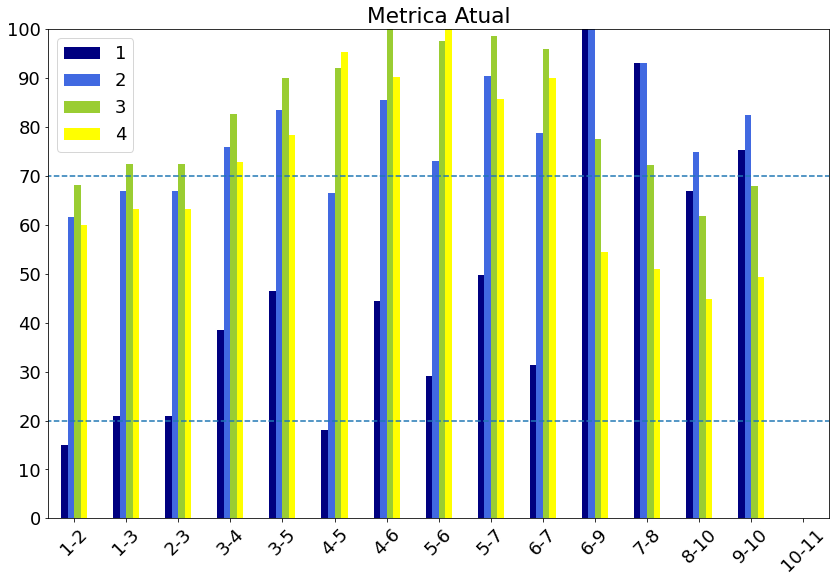

In [31]:
df = le_cfbs()
faz_plot(df, "Metrica Atual")

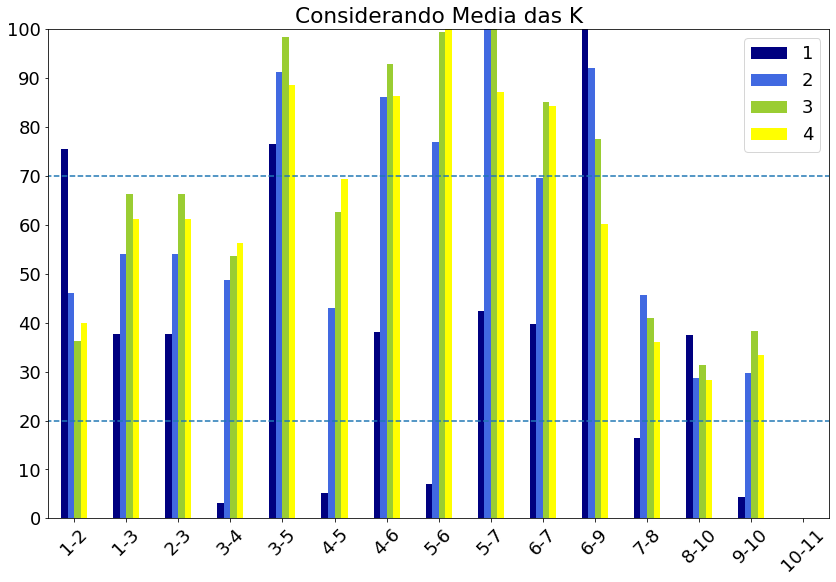

In [30]:
df = le_cfbs()
faz_plot(df, "Considerando Media das K")

In [12]:
df.iloc[0, :].tolist()

[1, 2]